In [1320]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [1321]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [1322]:
FIT = FitSpectrum()
DP = DP()

dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0430_all_test.fits')
# dps_df = dps_df[dps_df['BPT_1COMP']==16].copy()
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list(), subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 41.39 seconds.
Total number of spectra: 57271


In [1443]:
test_idx = dps_df[dps_df['TARGETID'] == 39627799866119506].index[0]
# test_idx = np.random.randint(0, len(ALL_SPECTRA.df))
test_id = ALL_SPECTRA.df.iloc[test_idx]["TARGETID"]
# print(f'TARGETID: {test_id}')
lam = desi_wavelength / (1+ALL_SPECTRA.df.iloc[test_idx]['Z'])

In [1444]:
test_df = ALL_SPECTRA.df.iloc[test_idx]
print(test_df)

TARGETID    39627799866119506
RA                  182.46229
DEC                  0.618985
Z                    0.121951
SPECTYPE               GALAXY
LOGM                10.527673
LOGSFR               0.855794
Name: 39771, dtype: object


In [1445]:
params = []
models = []
chisqs = []
for i in range(4):
    param, (combine_lam, combine_flux, combine_sigma, combine_model), slice_indices, _, _ = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=i+1)
    model = np.sum([
        model_vel(lam, gaussian_parms=param['gaussian_params'][j]) for j in range(len(param['gaussian_params']))
    ], axis=0)
    chisq = np.sum((combine_flux - combine_model)**2 / combine_sigma**2)
    params.append(param)
    models.append(model)
    chisqs.append(chisq)

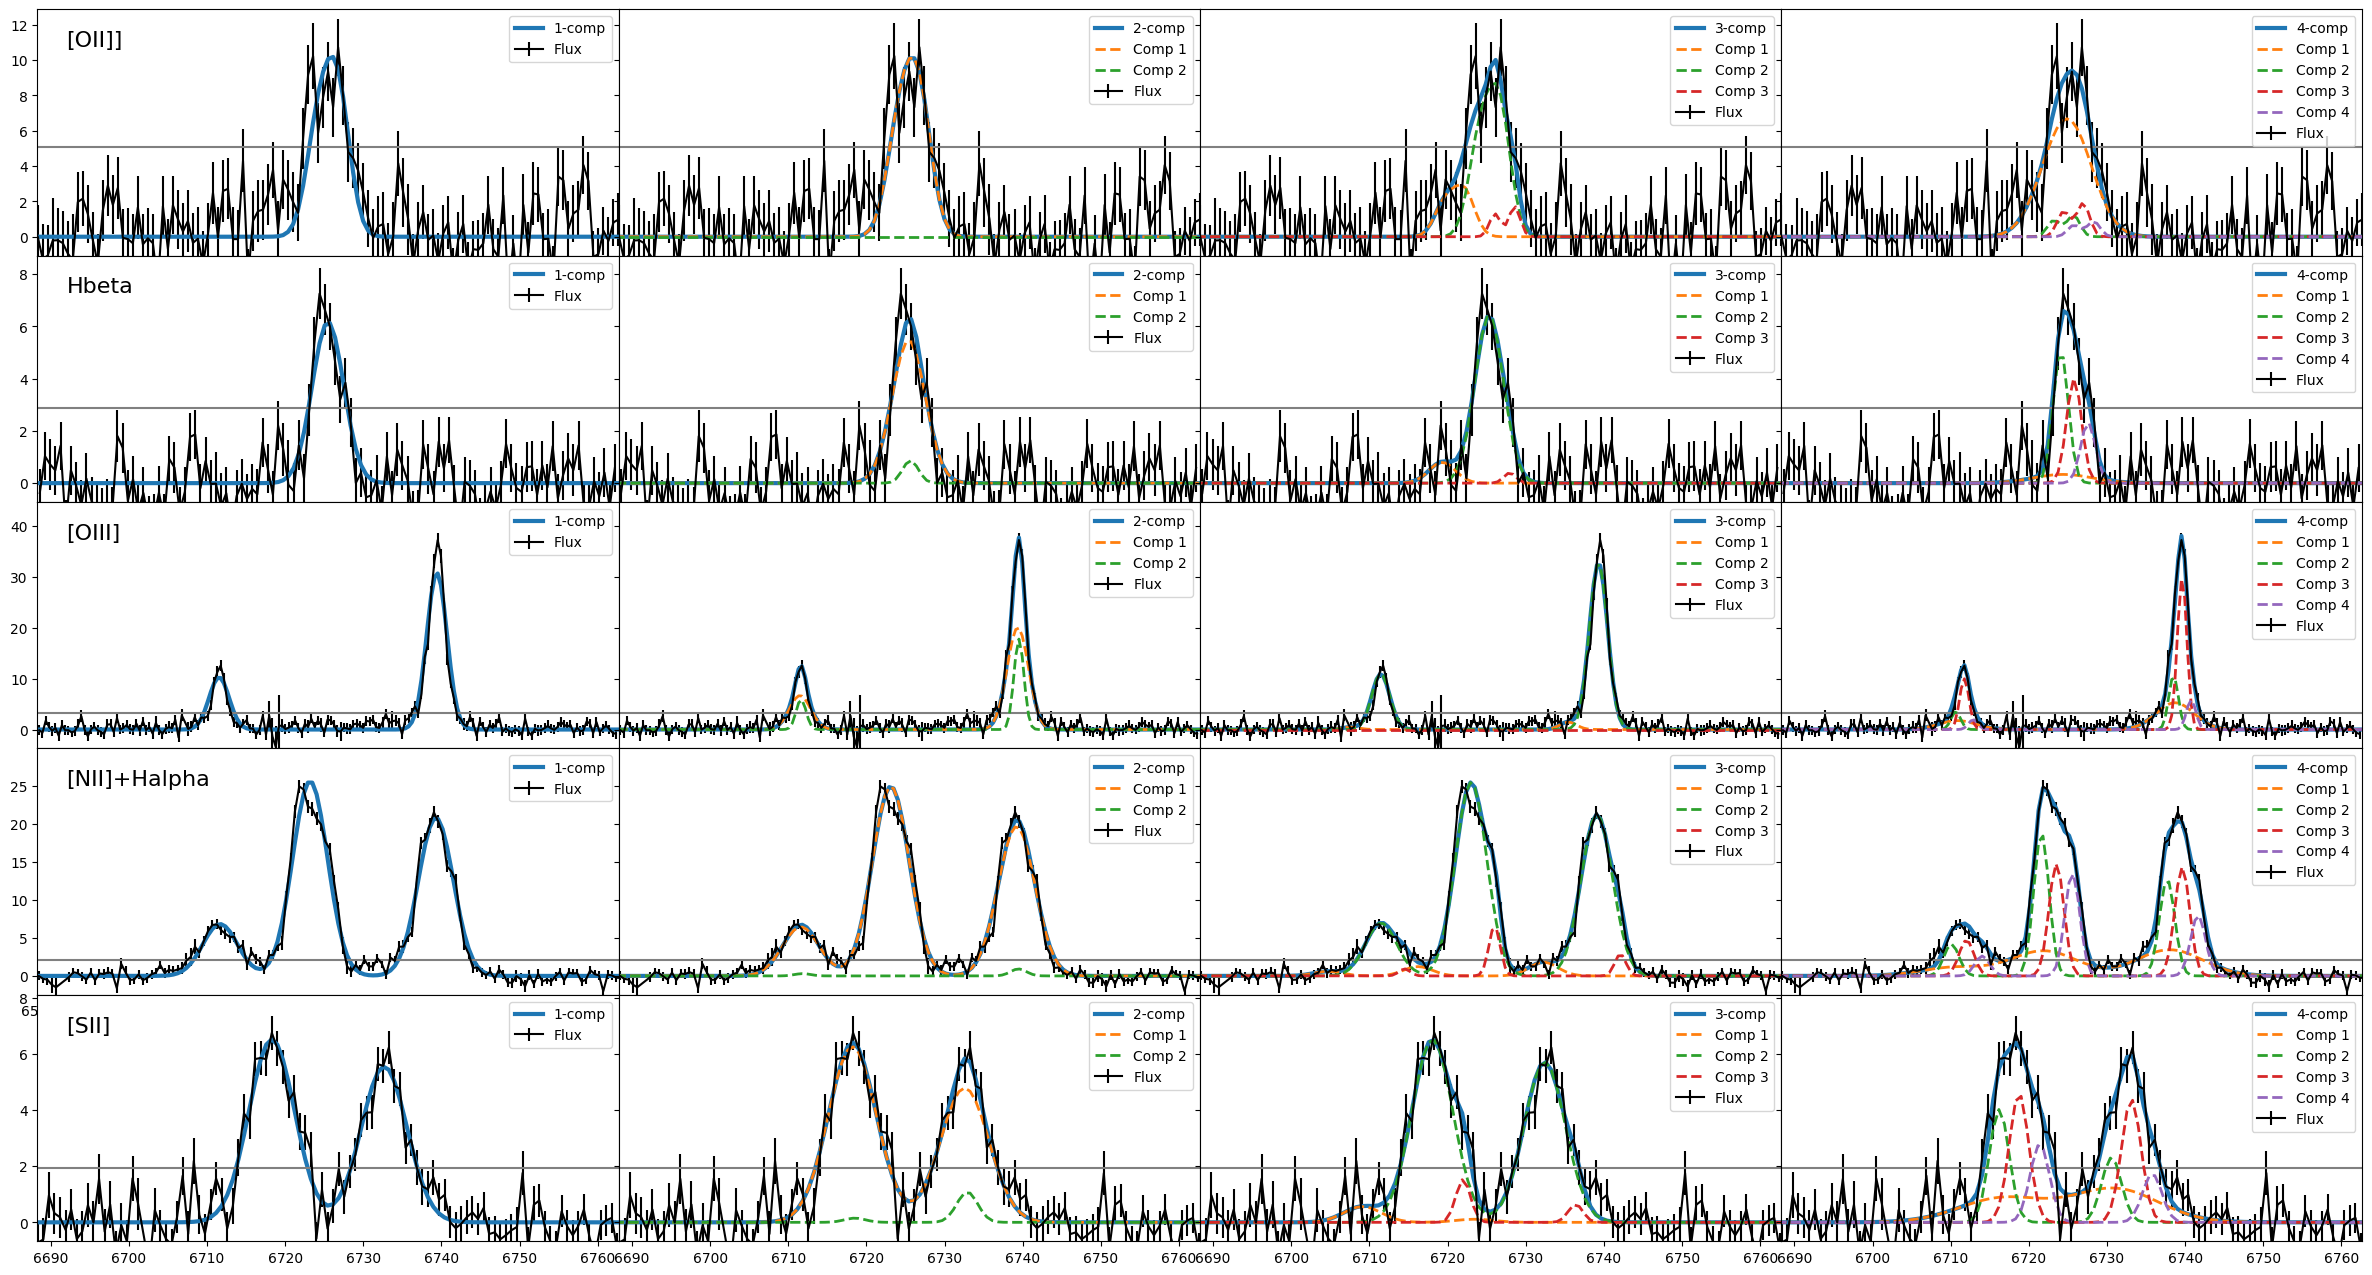

In [1446]:
plot_ranges = [
    (OII_rest[0]-40, OII_rest[1]+40),
    (Hbeta_rest[0]-40, Hbeta_rest[0]+40),
    (OIII_rest[0]-40, OIII_rest[1]+40),
    (NII_rest[0]-30, NII_rest[1]+30),
    (SII_rest[0]-30, SII_rest[1]+30)
]


fig, axes = plt.subplots(len(plot_ranges), len(models), figsize=(6*len(plot_ranges), 4*len(models)), sharey='row')
plt.subplots_adjust(wspace=0., hspace=0.)

lam_split  = np.split(combine_lam, slice_indices)
flux_split = np.split(combine_flux, slice_indices)
sigma_split = np.split(combine_sigma, slice_indices)


snr = 3




for i, (model, param) in enumerate(zip(models, params)):
    for k, ranges in enumerate(plot_ranges):
        ax = axes[k, i]
        ax.errorbar(lam_split[k], flux_split[k], yerr=sigma_split[k], label='Flux', color='k')
        ax.plot(lam, model, label=f'{i+1}-comp', lw=3)
        ax.axhline(snr*np.mean(sigma_split[k]), color='gray')

        if i !=0:
            for j in range(len(param['components'])):
                comp = np.sum([
                    model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
                ], axis=0)
                ax.plot(lam, comp, label=f'Comp {j+1}', lw=2, ls='--')

        ax.set_xlim(ranges)
        ax.set_ylim(bottom=-np.max(flux_split[k])*0.1, top=np.max(flux_split[k])*1.2)
        # ax.set_ylim(bottom=-1*np.mean(sigma_split[k]), top=10*np.mean(sigma_split[k]))
        ax.legend()

axes[0, 0].text(0.05, 0.85, '[OII]]', transform=axes[0, 0].transAxes, fontsize=16)
axes[1, 0].text(0.05, 0.85, 'Hbeta', transform=axes[1, 0].transAxes, fontsize=16)
axes[2, 0].text(0.05, 0.85, '[OIII]', transform=axes[2, 0].transAxes, fontsize=16)
axes[3, 0].text(0.05, 0.85, '[NII]+Halpha', transform=axes[3, 0].transAxes, fontsize=16)
axes[4, 0].text(0.05, 0.85, '[SII]', transform=axes[4, 0].transAxes, fontsize=16)

plt.show()

Best model: 4-Component

Delta BIC relative to best model:
1-Component: Delta BIC = 189.8437
2-Component: Delta BIC = 112.6850
3-Component: Delta BIC = 127.2064
4-Component: Delta BIC = 0.0000


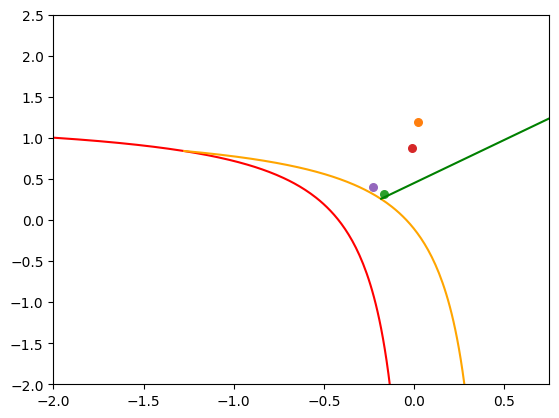

In [1447]:
# Calculate BIC for each model

n_data = len(combine_lam)
ks = [9, 18, 27, 36, 45]
bics = []
for i in range(len(models)):
    bics.append(ks[i] * np.log(n_data) + chisqs[i])


# Find best model (lowest BIC)
bic_values = np.array(bics)
best_model = np.argmin(bic_values) + 1
delta_bic = bic_values - np.min(bic_values)

print(f"Best model: {best_model}-Component")
print("\nDelta BIC relative to best model:")

for i, dbic in enumerate(delta_bic, start=1):
    print(f"{i}-Component: Delta BIC = {dbic:.4f}")

best_model=4

Hbeta = np.array(params[best_model-1]['amps'][1])
OIII = np.array(params[best_model-1]['amps'][2][1::2])
Halpha = np.array(params[best_model-1]['amps'][3][2*best_model:])
NII = np.array(params[best_model-1]['amps'][3][:2*best_model][1::2])


logoiii_hb = np.log10(OIII / Hbeta)
lognii_ha = np.log10(NII / Halpha)
if best_model != 1:
    for i in range(len(lognii_ha)):
        plt.scatter(lognii_ha[i], logoiii_hb[i], c=['C1', 'C2', 'C3', 'C4', 'C5'][i], s=30)
else:
    plt.scatter(lognii_ha, logoiii_hb, c='C0', s=30)

x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 2.5))
plt.show()

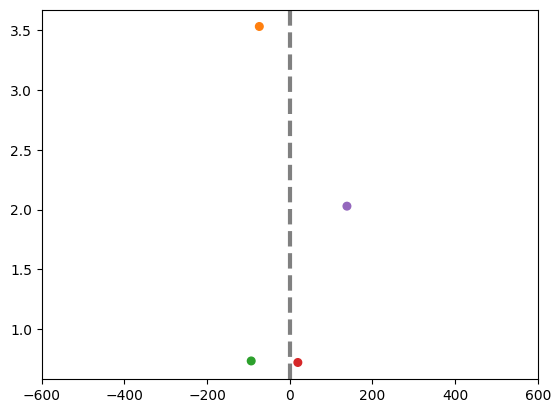

In [1448]:
plt.scatter(params[best_model-1]['dv'], reddening(Halpha, Hbeta), c=['C1', 'C2', 'C3', 'C4', 'C5'][0:best_model], s=30)
plt.axvline(0, lw=3, ls='--', color='gray')
plt.xlim((-600, 600))
# plt.ylim(bottom=0)
plt.show()

In [1449]:
print(params[3]['dv'])
print(params[3]['sigma'])

(np.float64(-73.55927311702983), np.float64(-93.1813715564927), np.float64(19.6587598316862), np.float64(138.43587141913443))
(np.float64(244.8146528283109), np.float64(46.8490806342785), np.float64(46.080701043626725), np.float64(45.25198829637308))


In [1450]:
print(params[2]['dv'])
print(params[2]['sigma'])

(np.float64(-410.0594580503039), np.float64(-11.043412116077418), np.float64(164.59197403793772))
(np.float64(103.14413435309959), np.float64(113.0864911131447), np.float64(27.05051224089453))


In [1451]:
print(params[1]['dv'])
print(params[1]['sigma'])

(np.float64(-4.019960497471721), np.float64(10.541848688989043))
(np.float64(134.3588945102709), np.float64(50.58990513559927))


In [1452]:
print(params[0]['sigma'])

126.59942898397516


In [1453]:
print(params[3]['dv_err'])
print(params[3]['sigma_err'])

(np.float64(21.884875331590518), np.float64(7.206505866227574), np.float64(4.738470985412539), np.float64(7.994177388047909))
(np.float64(17.77352032777165), np.float64(5.079898524062746), np.float64(7.974199191070166), np.float64(6.260322250975469))


In [1454]:
print(params[3]['amps'][2][::2])
print(params[3]['amps_err'][2][::2])

[np.float64(1.7540046048980051), np.float64(3.524434319252439), np.float64(9.959516859967843), np.float64(1.9323752584090865)]
[np.float64(0.3129470401643469), np.float64(0.941530550399647), np.float64(0.5128342485123752), np.float64(0.6861507154463761)]


In [1455]:
print(params[3]['amps'][2][1::2])
print(params[3]['amps_err'][2][1::2])

[np.float64(5.262013814694016), np.float64(10.573302957757317), np.float64(29.878550579903532), np.float64(5.79712577522726)]
[np.float64(0.9388411204930407), np.float64(2.824591651198941), np.float64(1.5385027455371258), np.float64(2.0584521463391283)]


In [1456]:
print(params[3]['amps'][3][:8][::2])
print(params[3]['amps_err'][3][:8][::2])

[np.float64(1.1302401919641931), np.float64(4.181070306744411), np.float64(4.6993242939479885), np.float64(2.6267350081411123)]
[np.float64(0.20285204044397917), np.float64(0.49906519882139394), np.float64(0.4976984556290878), np.float64(0.3757772271040763)]


In [1457]:
print(params[3]['amps'][3][:8][1::2])
print(params[3]['amps_err'][3][:8][1::2])

[np.float64(3.447232585490789), np.float64(12.752264435570453), np.float64(14.332939096541363), np.float64(8.011541774830391)]
[np.float64(0.6186987233541364), np.float64(1.5221488564052514), np.float64(1.5179802896687178), np.float64(1.1461205426674326)]


In [1458]:
n_comp = 4
OII3726_amp = params[n_comp-1]['amps'][0][::2]
OII3729_amp = params[n_comp-1]['amps'][0][1::2]
Hbeta_amp = params[n_comp-1]['amps'][1]
OIII4959_amp = params[n_comp-1]['amps'][2][::2]
OIII5007_amp = params[n_comp-1]['amps'][2][1::2]
NII6548_amp = params[n_comp-1]['amps'][3][:n_comp*2][::2]
Halpha_amp = params[n_comp-1]['amps'][3][n_comp*2:]
NII6583_amp = params[n_comp-1]['amps'][3][:n_comp*2][1::2]
SII6716_amp = params[n_comp-1]['amps'][4][:n_comp*2]
SII6731_amp = params[n_comp-1]['amps'][4][n_comp*2:]

In [1459]:
print(np.concatenate(params[3]['components'][0]['amps']))
print(np.concatenate(params[3]['components'][0]['amps_err']))


[3.15742088 4.19936977 0.33326608 1.7540046  5.26201381 1.13024019
 3.44723259 3.29049224 0.86050648 1.19103194]
[0.85251172 1.13384058 0.6293579  0.31294704 0.93884112 0.20285204
 0.61869872 0.64792207 0.35288851 0.35342961]


In [1460]:
print(params[3]['dv'])
print(params[3]['sigma'])
print(params[3]['lam0s'])

(np.float64(-73.55927311702983), np.float64(-93.1813715564927), np.float64(19.6587598316862), np.float64(138.43587141913443))
(np.float64(244.8146528283109), np.float64(46.8490806342785), np.float64(46.080701043626725), np.float64(45.25198829637308))
[[np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032)], [np.float64(4862.691039788272), np.float64(4862.691039788272), np.float64(4862.691039788272), np.float64(4862.691039788272)], [np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203)], [np.float64(6549.8590281116185), np.float64(6585.27854800011), np.float64(6549.8590281116185), np.float64(6585.27854800011), n

In [1461]:
lum_comp1 = lum(flux(np.concatenate(params[3]['components'][0]['amps']), 
                     params[3]['sigma'][0], 
                     np.concatenate(params[3]['components'][0]['lam0s']), 
                     params[3]['dv'][0]), 
                z=0.01)
print(lum_comp1)

[5.74381189e+54 7.64497549e+54 7.90979885e+53 4.24654645e+54
 1.28627769e+55 3.61326944e+54 1.10800669e+55 1.05431141e+55
 2.82169987e+54 3.91388687e+54]


In [1462]:
from scipy.stats import f

F_stat_12 = ((chisqs[0] - chisqs[1]) / (ks[1]-ks[0])) / (chisqs[1] / (n_data-ks[1]))
p_value_12 = 1 - f.cdf(F_stat_12, ks[1]-ks[0], n_data-ks[1])
if p_value_12 > 0.05:
    print("1-Component")
else:
    F_stat_23 = ((chisqs[1] - chisqs[2]) / (ks[2]-ks[1])) / (chisqs[2] / (n_data-ks[2]))
    p_value_23 = 1 - f.cdf(F_stat_23, ks[2]-ks[1], n_data-ks[2])
    if p_value_23 > 0.05:
        print("2-Component")
    else:
        F_stat_34 = ((chisqs[2] - chisqs[3]) / (ks[3]-ks[2])) / (chisqs[3] / (n_data-ks[3]))
        p_value_34 = 1 - f.cdf(F_stat_34, ks[3]-ks[2], n_data-ks[3])
        if p_value_34 > 0.05:
            print("3-Component")
        else:
            print("4-Component")



4-Component
